In [85]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
import tensorflow.keras.backend as K
import tensorflow as tf
import collections

In [86]:
# 1. Ruta local donde guardaste el CSV preprocesado
ruta_csv = r"C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\processed\df_preprocesado_LSTM.csv"

# 2. Cargar el DataFrame
df = pd.read_csv(ruta_csv, parse_dates=['FECHA_CIERRE'])

In [95]:
df.columns

Index(['NUMERO DE LA COLOCACION', 'NUMERO DE IDENTIFICACION DEUDOR',
       'NUMERO DEL PRODUCTO', 'PLAZO EN DIAS', 'NUMERO DE PAGOS PACTA',
       'VALOR ORIGINAL DEL PR', 'CAPITAL PEND POR FACT', 'SALDO DEL PRESTAMO',
       'NRO PLAN PAGOS VIGENT', 'NRO DE UTILIZACINES D', 'DIAS DE MORA',
       'CALIFICACION CARTERA', 'VLR ULTIMO PAGO', 'VLR TASA', 'VLR CUOTA MES',
       'VLR MINIMO DE PAGO', 'DIA VENCIMIENTO CUOTA', 'NRO CUOTAS VENCIDAS',
       'NRO CUOTAS PAGADAS', 'NRO CUOTAS RESTANTE', 'NIVEL DE ESTUDIOS',
       'MARCA', 'ACIERTA', 'ANTIGÜEDAD LABORAL', 'NUMERO DE PERSONAS A CARGO',
       'INGRESOS', 'PRODUCTO', 'FECHA_CIERRE', 'MORA_ACTUAL', 'MORA_SIGUIENTE',
       'ETIQUETA_MORA', 'ANTIGUEDAD_CREDITO_MESES', 'DIAS_HASTA_PROX_PAGO',
       'DIAS_DESDE_ULTIMO_PAGO', 'DIAS_CUOTA_PENDIENTE',
       'TIPO DE SOLICITANTE_INDEPENDIENTE',
       'TIPO DE SOLICITANTE_SIN INFORMACION', 'TIPO DE SOLICITANTE_TAXISTA',
       'TIPO DE SOLICITANTE_TRANSPORTADOR', 'TIPO DE ID_CEDULA',


In [87]:
# 2. Convertir columnas booleanas a enteros (si hay)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# 3. Parámetros
timesteps = 10
target_col = 'ETIQUETA_MORA'

# 4. Seleccionar solo columnas numéricas (excluyendo ID, fecha, y target)
feature_cols = df.select_dtypes(include=[np.number]).columns.difference([target_col, 'NUMERO DE LA COLOCACION'])

# 5. Ordenar por crédito y fecha
df = df.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

# 6. Crear secuencias
X_sequences = []
y_targets = []

for _, group in df.groupby('NUMERO DE LA COLOCACION'):
    group = group.reset_index(drop=True)
    
    for i in range(len(group) - timesteps):
        X_seq = group.loc[i:i+timesteps-1, feature_cols].values
        y_val = group.loc[i+timesteps, target_col]
        
        if not np.isnan(X_seq).any() and not pd.isna(y_val):
            X_sequences.append(X_seq)
            y_targets.append(y_val)

# 7. Convertir a arrays
X_lstm = np.array(X_sequences)
y_lstm = np.array(y_targets)

# 8. Mostrar forma
print(f"Secuencias generadas: X_lstm.shape = {X_lstm.shape}, y_lstm.shape = {y_lstm.shape}")

Secuencias generadas: X_lstm.shape = (8150, 10, 62), y_lstm.shape = (8150,)


In [88]:
# Paso 1: ordenar bien antes de construir
df = df.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

# Paso 2: revisar si alguna secuencia tiene dtype extraño
for i, seq in enumerate(X_lstm[:5]):
    print(f"Secuencia {i} forma: {seq.shape}, tipo: {seq.dtype}")


Secuencia 0 forma: (10, 62), tipo: float64
Secuencia 1 forma: (10, 62), tipo: float64
Secuencia 2 forma: (10, 62), tipo: float64
Secuencia 3 forma: (10, 62), tipo: float64
Secuencia 4 forma: (10, 62), tipo: float64


In [89]:
# Ver un ejemplo del grupo con etiquetas
group_ejemplo = df[df['NUMERO DE LA COLOCACION'] == df['NUMERO DE LA COLOCACION'].iloc[0]]
group_ejemplo = group_ejemplo.sort_values('FECHA_CIERRE').reset_index(drop=True)

# Mostrar últimas 13 filas para ver secuencia + target
group_ejemplo[['FECHA_CIERRE', 'ETIQUETA_MORA']].tail(13)


,FECHA_CIERRE,ETIQUETA_MORA
1,2024-02-28,3
2,2024-03-30,3
3,2024-04-29,3
4,2024-05-30,3
5,2024-06-29,3
6,2024-07-31,3
7,2024-08-31,3
8,2024-09-30,3
9,2024-10-31,3
10,2024-11-30,3


In [90]:
# Conteo de clases
conteo = collections.Counter(y_lstm)
total = len(y_lstm)

print("Distribución de clases en las secuencias (y_lstm):")
for clase, cantidad in sorted(conteo.items()):
    porcentaje = cantidad / total * 100
    print(f"Clase {clase}: {cantidad} secuencias ({porcentaje:.2f}%)")

Distribución de clases en las secuencias (y_lstm):
Clase 0: 4760 secuencias (58.40%)
Clase 1: 274 secuencias (3.36%)
Clase 2: 202 secuencias (2.48%)
Clase 3: 2914 secuencias (35.75%)


In [91]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split

# Paso 1: Aplanar cada secuencia 3D en 2D para aplicar SMOTE
n_timesteps = X_lstm.shape[1]
n_features = X_lstm.shape[2]
X_flat = X_lstm.reshape((X_lstm.shape[0], n_timesteps * n_features))

# Paso 2: Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_lstm)

# Paso 3: Volver a dar forma a los datos a 3D
X_lstm_bal = X_resampled.reshape((-1, n_timesteps, n_features))
y_lstm_bal = y_resampled

# Mostrar clases después del balanceo
print(f"✅ Dataset balanceado: {X_lstm_bal.shape}, Clases: {Counter(y_lstm_bal)}")

✅ Dataset balanceado: (19040, 10, 62), Clases: Counter({3: 4760, 0: 4760, 1: 4760, 2: 4760})


In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2

# Focal Loss personalizada
def focal_loss(gamma=2., alpha=None):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        
        if alpha is not None:
            alpha_tensor = tf.convert_to_tensor(alpha, dtype=tf.float32)
            cross_entropy *= alpha_tensor
        
        weight = K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        
        return K.mean(K.sum(loss, axis=1))  # <- importante
    return loss

# One-hot encoding de etiquetas
y_cat = to_categorical(y_lstm, num_classes=4)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_cat, test_size=0.2, random_state=42, stratify=y_lstm
)

# Definir modelo
model = Sequential()
model.add(Bidirectional(LSTM(64, kernel_regularizer=l2(0.001), return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(4, activation='softmax'))

# Compilar modelo con focal loss y pesos por clase (ajustar según tus datos si es necesario)
alpha_weights = [0.25, 4.0, 4.0, 0.5]  # mayor peso a clases 1 y 2
model.compile(optimizer='adam',
              loss=focal_loss(gamma=2., alpha=alpha_weights),
              metrics=['accuracy'])

# Entrenar modelo
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Evaluar
loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Accuracy en test: {acc:.4f}")

Epoch 1/100


c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4163 - loss: 0.6532 - val_accuracy: 0.5468 - val_loss: 0.3994
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5294 - loss: 0.4238 - val_accuracy: 0.5782 - val_loss: 0.3829
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4900 - loss: 0.4419 - val_accuracy: 0.4900 - val_loss: 0.3971
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4322 - loss: 0.4512 - val_accuracy: 0.3658 - val_loss: 0.4317
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3969 - loss: 0.4798 - val_accuracy: 0.3650 - val_loss: 0.4273
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3334 - loss: 0.4614 - val_accuracy: 0.4586 - val_loss: 0.4255
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4278 - loss: 0.4573 - val_accuracy: 0.4057 - val_loss: 0.4231
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4043 - loss: 0.4666 - val_accuracy: 0.5230 - val_loss: 

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
📋 Reporte de Clasificación:
                     precision    recall  f1-score   support

          0: Al día       0.79      0.48      0.60       952
      1: Entra mora       0.04      0.15      0.06        55
       2: Sale mora       0.00      0.00      0.00        40
3: Se mantiene mora       0.53      0.75      0.62       583

           accuracy                           0.55      1630
          macro avg       0.34      0.34      0.32      1630
       weighted avg       0.65      0.55      0.57      1630



C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24404\1852765464.py:21: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


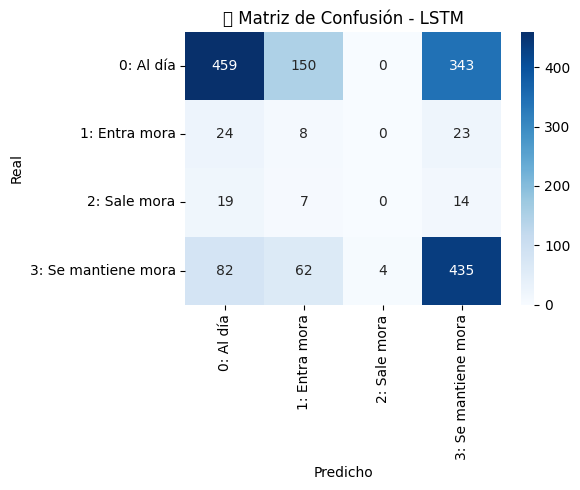

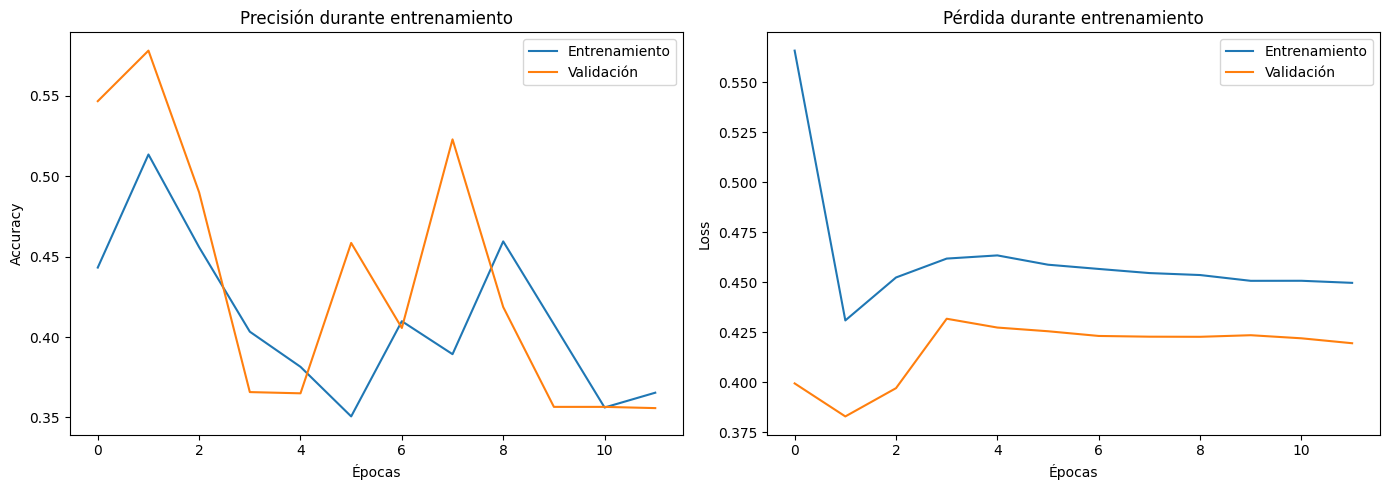

In [93]:
# 1. Obtener predicciones
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Reporte de clasificación
print("📋 Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=[
    "0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"
]))

# 3. Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"],
            yticklabels=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"])
plt.title("🔍 Matriz de Confusión - LSTM")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# 4. Gráfica de precisión y pérdida
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()